In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

c:\Users\Dell\LangGraph\env0\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
model=ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

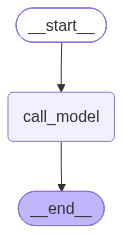

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Nitish."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Nitish.


"Hi Nitish! Nice to meet you.\n\nI'm an AI assistant, and I don't have a personal name. You can just call me AI or assistant.\n\nHow can I help you today?"

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 63
Hi, my name is Nitish.
Hi Nitish! Nice to meet you.

I'm an AI assistant, and I don't have a personal name. You can just call me AI or assistant.

How can I help you today?
I am learning LangGraph.


'That\'s a fantastic topic to be learning! LangGraph is a powerful framework for building robust, stateful, and multi-agent applications with LLMs, especially when you need complex control flow, loops, and human-in-the-loop interactions.\n\nIt builds on LangChain concepts but introduces the idea of defining computations as a graph, which allows for much more sophisticated orchestration.\n\nHow can I help you with your LangGraph learning journey? For example, are you:\n\n*   **Just getting started** and looking for an introduction or a basic "hello world" example?\n*   **Exploring specific concepts** like state, nodes, edges, conditional routing, checkpoints, or memory?\n*   **Working on a particular project** and need help with implementation details or design patterns?\n*   **Running into any issues or errors** with your code?\n*   **Looking for best practices** or advanced patterns?\n*   **Wanting to compare** it with other tools or understand its advantages?\n\nFeel free to ask me a

In [14]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 86
What is my name?
As an AI, I don't have access to personal information about you, including your name. I don't know who you are in the real world.

Therefore, I don't know your name. If you'd like to tell me, I'll remember it for our current conversation.
Can you explain short term memory?


'Short-term memory (STM) is a temporary storage system that holds a limited amount of information for a brief period, allowing us to actively process and use it in the moment. Think of it as your brain\'s "mental scratchpad" or "active desktop."\n\nHere\'s a breakdown of its key characteristics and how it works:\n\n1.  **Limited Capacity:**\n    *   STM can only hold a small amount of information at any given time.\n    *   The classic research by George A. Miller (1956) suggested the "magic number seven, plus or minus two" items (i.e., between 5 and 9 pieces of information).\n    *   However, what constitutes an "item" can vary. We can overcome this limitation through **chunking**, where we group smaller bits of information into larger, more meaningful units (e.g., remembering a phone number as three chunks: 555-123-4567 instead of ten individual digits).\n\n2.  **Brief Duration:**\n    *   Information in STM typically lasts for about **15 to 30 seconds** if it\'s not actively rehears

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


"As an AI, I don't have access to personal information about you, including your name. I don't know who you are in the real world.\n\nTherefore, I don't know your name. If you'd like to tell me, I'll remember it for our current conversation."

In [15]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Nitish.
------------------------------------------------------------------------------------------------------------------------
Hi Nitish! Nice to meet you.

I'm an AI assistant, and I don't have a personal name. You can just call me AI or assistant.

How can I help you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That's a fantastic topic to be learning! LangGraph is a powerful framework for building robust, stateful, and multi-agent applications with LLMs, especially when you need complex control flow, loops, and human-in-the-loop interactions.

It builds on LangChain concepts but introduces the idea of defining computations as a graph, which allows for much more sophisticated orchestration.

How can I help you with your LangGraph learning jour